In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# Jupyter visualization settings
%config InlineBackend.figure_format = 'retina'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

In [2]:
# load dataset
iris = load_iris()
X, y = iris.data, iris.target
feature_names, target_names = iris.feature_names, iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['species'] = df['target'].map({i: name for i, name in enumerate(target_names)})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
# split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'train shape: {X_train.shape}, test shape: {X_test.shape}')

train shape: (120, 4), test shape: (30, 4)


In [4]:
# train Decision Tree Classifier
clf = DecisionTreeClassifier(criterion='gini', max_depth=3,
                             min_samples_split=2, min_samples_leaf=1, random_state=42)
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [5]:
# predict on test set
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {accuracy:.4f}')

Test Accuracy: 0.9667


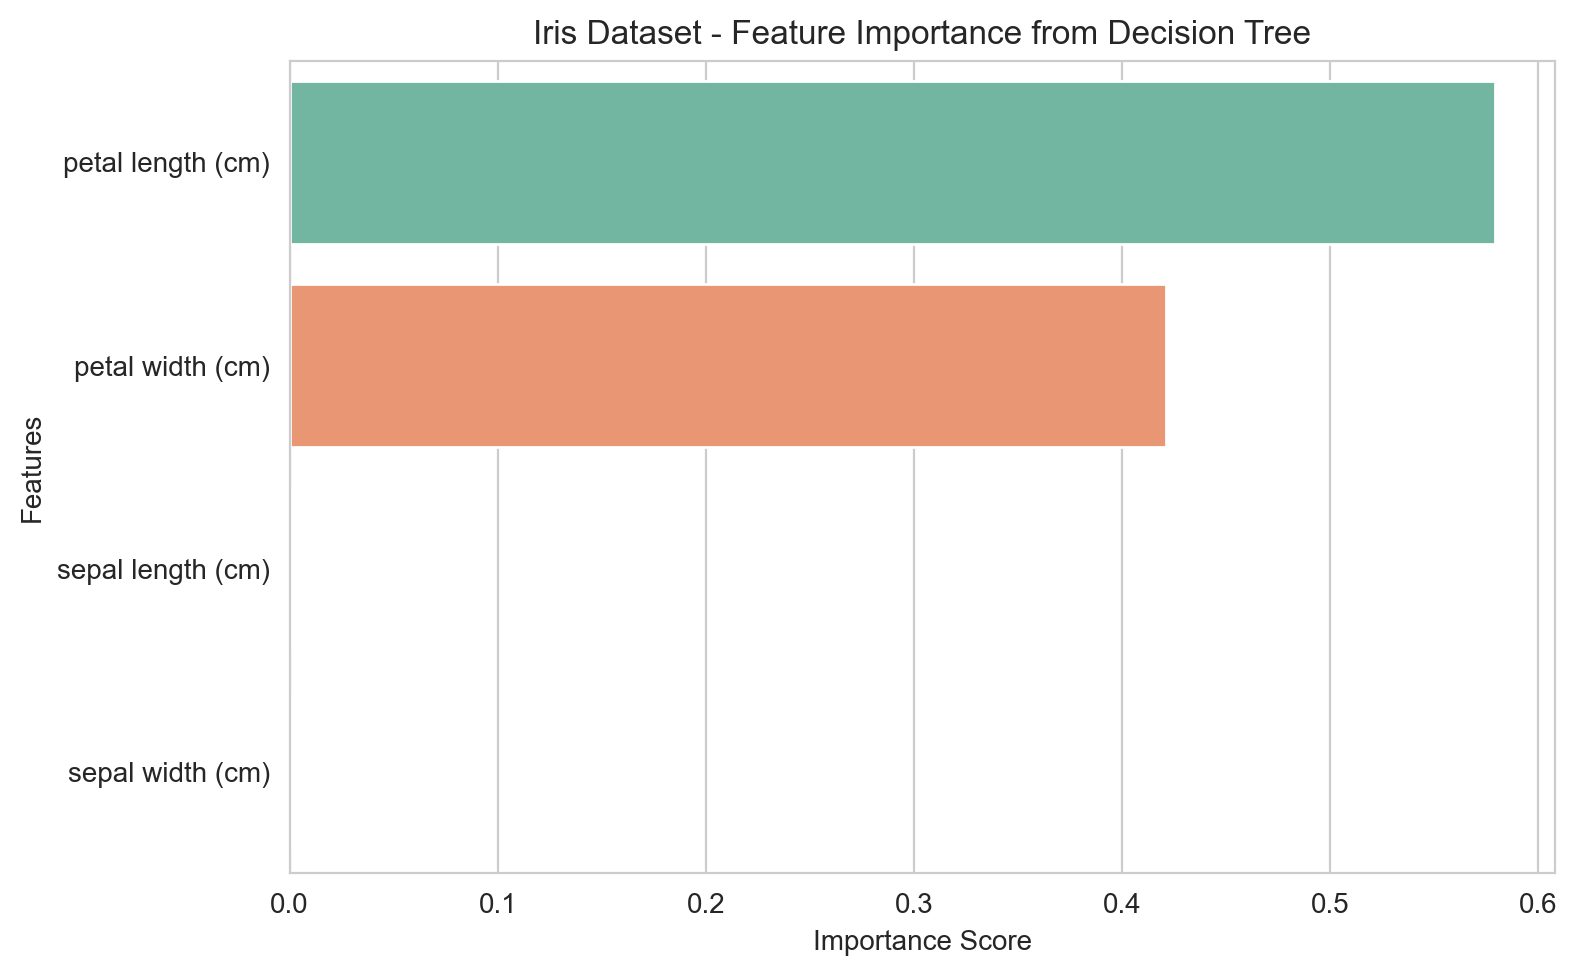

In [6]:
# feature importance
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': clf.feature_importances_}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='Set2', hue='Feature', dodge=False)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Iris Dataset - Feature Importance from Decision Tree')
plt.tight_layout()
plt.show()

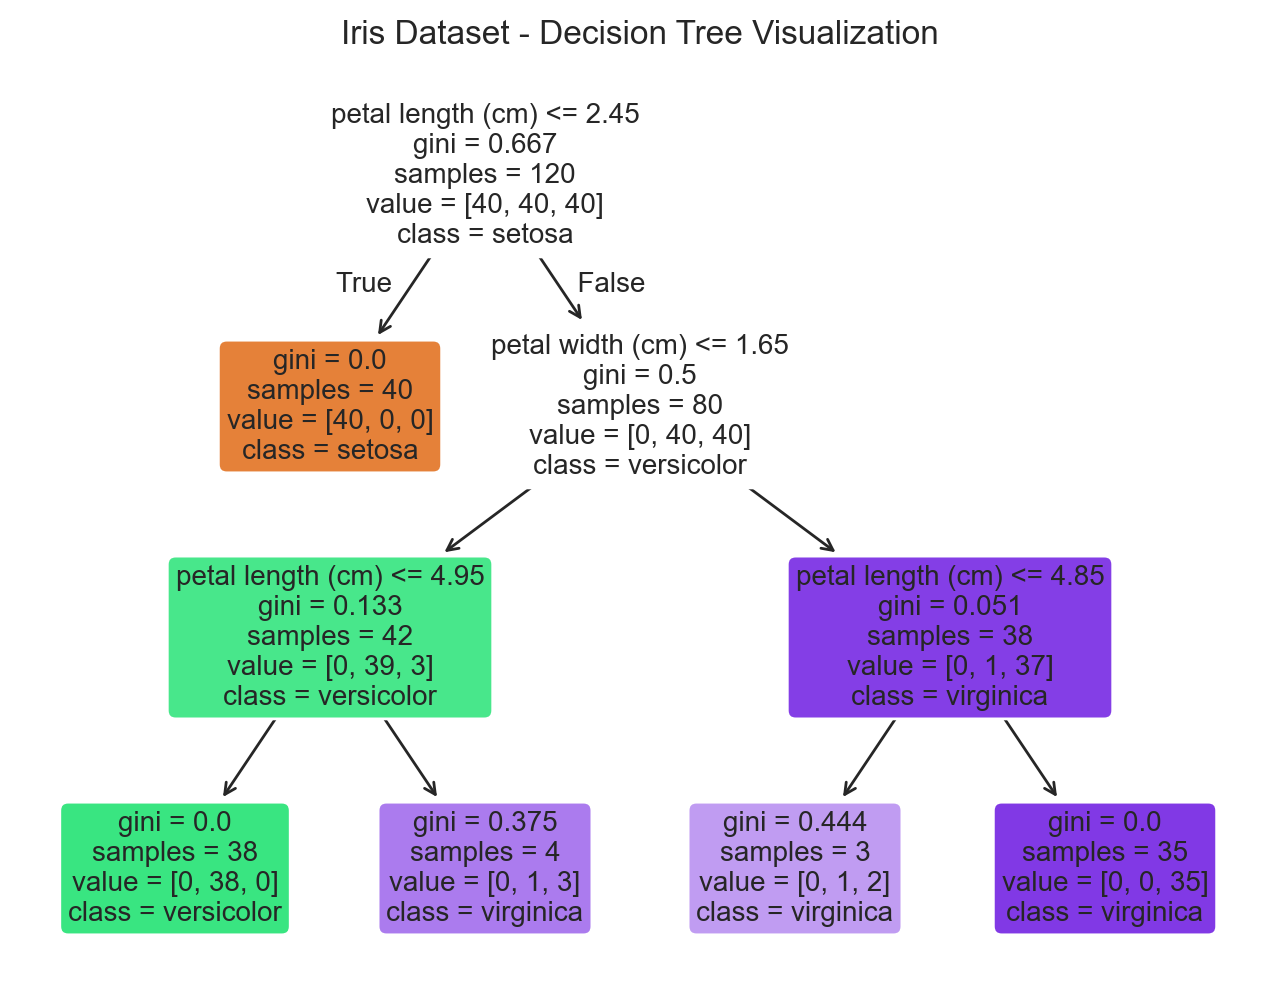

In [7]:
plt.figure(figsize=(8, 6))
plot_tree(clf, feature_names=feature_names, class_names=target_names,
          filled=True, rounded=True, fontsize=10)
plt.title("Iris Dataset - Decision Tree Visualization")
plt.show()